In [4]:
%load_ext autoreload
%autoreload 2
from PyPDF2 import PdfReader
import os
import amrlib
import penman
import torch
from amrlib import load_stog_model
import networkx as nx
import sys, os
from pyvis.network import Network
import matplotlib.pyplot as plt
import amrlib
import spacy
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from kg.formatting.formatting_manager import FormattingManager
import sys, importlib,os
sys.modules.pop('PatentTextFormatter', None)
importlib.invalidate_caches()



c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import torch, os, platform

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)   # None == CPU-only build
print("gpu count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("name[0]:", torch.cuda.get_device_name(0))
    print("capability[0]:", torch.cuda.get_device_capability(0))
else:
    print("No CUDA device visible to PyTorch.")

torch: 2.7.1+cu128
cuda available: True
torch.version.cuda: 12.8
gpu count: 1
name[0]: NVIDIA GeForce RTX 5070 Ti
capability[0]: (12, 0)


In [2]:
formatterManager = FormattingManager()
segment_split = formatterManager.split_segments("A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.")
print("split" + str(segment_split))

split['A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.']


In [3]:
nlp = spacy.load("en_core_web_sm")
formatterManager = FormattingManager()

for i in range(0,len(segment_split)):
    doc = nlp(segment_split[i])
    sentences = [sent.text.strip() for sent in doc.sents]
    print(sentences)
    segment_split[i] = sentences


NameError: name 'FormattingManager' is not defined

In [16]:


rule = formatterManager.rule_standardiser("something is designed by the product to do something")
print(rule)

        



Run sentence simplifier
[Sentence(text='[GENERIC] The product designs something to do something.', index=0, source='', span=None, id='7fe9f148-2aa6-4a92-9f83-92b433178337', kg_node_id=None, embedding=None, tokens=[], entities=[], tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en')]


In [4]:
simplify = formatterManager.simplify("A device configured to automatically regulate temperature based on detected user activity.")
print(simplify)



['a', 'device', 'configure', 'to', 'automatically', 'regulate', 'temperature', 'base', 'on', 'detect', 'user', 'activity', '.']


In [19]:
amrlib.__file__
stog = amrlib.load_stog_model()


FileNotFoundError: [Errno 2] No meta-data (amrlib_meta.json or hard-coded) available for: 'C:\\Users\\Caleb\\Documents\\LLM Patent Claim Generator Thesis\\.venv\\Lib\\site-packages\\amrlib\\data\\model_stog'

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the AMR model and move to GPU
stog = amrlib.load_stog_model()
if torch.cuda.is_available():
    stog.model.to('cuda')
    stog.device = torch.device('cuda')
else:
    stog.device = torch.device('cpu')
    
graphs = stog.parse_sents(['''A water tank for appreciation provided with a water storage, a water pipe, an air bubble generating member, wherein said water storage is provided with a water inlet port and an opening portion and said opening portion is so provided that the convection can be generated in said water tank for appreciation by the liquid current from a water tank through said opening portion, and said water storage is installed upwardly of a water tank for appreciation and one end of said water pipe is connected to an inlet water port of a water storage and the other end is so installed that it is in the liquid when the liquid is filled in a water tank for appreciation and an air bubble generating member is so installed that it can lead the air bubble inside of a water pipe in the peripheral portion of said other end of said water pipe and a display device for appreciation using said water tank for appreciation are used.'''])
for graph in graphs:
    print(graph)
g = penman.decode(graphs[0])
next(stog.model.parameters()).device


Sentence number 0 was clipped for length
gid=x Start paren present but generate-01 is not a new concept
gid=x Missing starting paren for node p7/portion
gid=x Start paren present but and is not a new concept
gid=x Start paren present but pipe is not a new concept


# ::snt A water tank for appreciation provided with a water storage, a water pipe, an air bubble generating member, wherein said water storage is provided with a water inlet port and an opening portion and said opening portion is so provided that the convection can be generated in said water tank for appreciation by the liquid current from a water tank through said opening portion, and said water storage is installed upwardly of a water tank for appreciation and one end of said water pipe is connected to an inlet water port of a water storage and the other end is so installed that it is in the liquid when the liquid is filled in a water tank for appreciation and an air bubble generating member is so installed that it can lead the air bubble inside of a water pipe in the peripheral portion of said other end of said water pipe and a display device for appreciation using said water tank for appreciation are used.
(a / and
      :op1 (p / provide-01
            :ARG1 (a2 / and
            

device(type='cuda', index=0)

In [9]:
import networkx as nx

# Build a MultiDiGraph from the AMR graph 'g'
nx_graph = nx.MultiDiGraph()

def add_node_if_missing(n, concept, kind="concept"):
    if not nx_graph.has_node(n):
        nx_graph.add_node(n, concept=str(concept), kind=kind)

# Pre-compute which variables are AMR instances (non-literals)
instance_vars = {s for s, r, t in g.triples if r == ":instance"}

# Add nodes/edges
for src, role, tgt in g.triples:
    if role == ":instance":
        # Concept node
        add_node_if_missing(src, tgt, kind="concept")
    else:
        # If target is not an instance var, treat as literal -> attach via a dummy node
        if tgt not in instance_vars:
            lit_id = f"{src}{role}{tgt}"
            add_node_if_missing(lit_id, str(tgt), kind="literal")
            nx_graph.add_edge(src, lit_id, role=role)
        else:
            nx_graph.add_edge(src, tgt, role=role)

# Ensure all referenced variables exist as nodes (even if :instance triple came later)
all_sources = {s for s, _, _ in g.triples}
for v in {t for _, _, t in g.triples if t in all_sources}:
    if not nx_graph.has_node(v):
        concept = next((t for s, r, t in g.triples if s == v and r == ":instance"), None)
        if concept is not None:
            add_node_if_missing(v, concept, kind="concept")

# Optional: annotate shapes/colors now for downstream drawing code
for n, d in nx_graph.nodes(data=True):
    if d.get("kind") == "concept":
        d["shape"] = "square"
        d["color"] = "#9ddaff"
    elif d.get("kind") == "literal":
        d["shape"] = "hexagon"
        d["color"] = "#fbe29c"
    else:
        d["shape"] = "circle"
        d["color"] = "#cbe5b6"

print(f"nodes: {nx_graph.number_of_nodes()}, edges: {nx_graph.number_of_edges()}")


nodes: 34, edges: 38


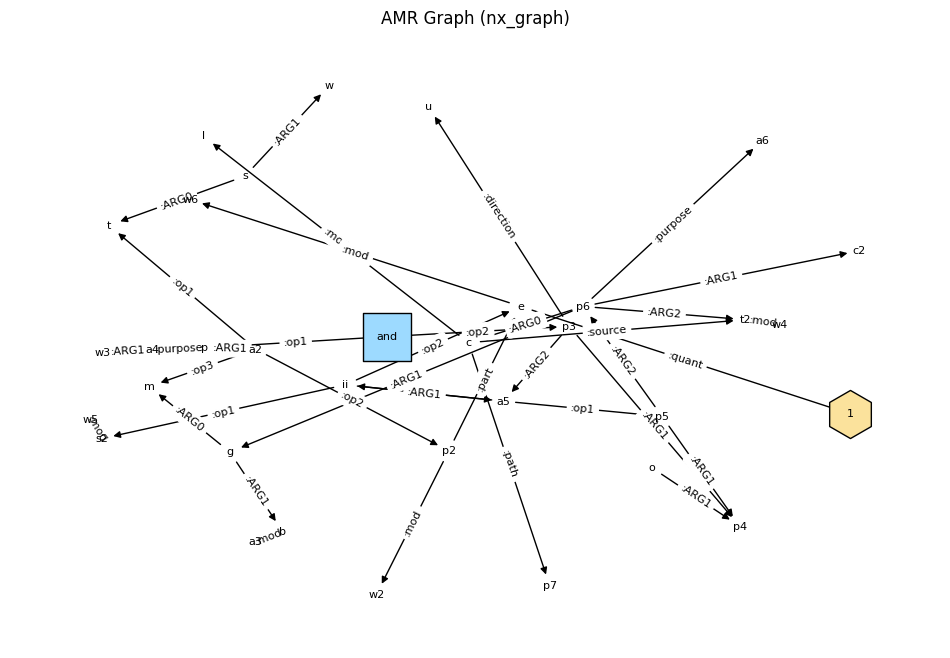

amr_graph.html
✅ Interactive graph written to amr_graph.html — open it in your browser or view inline below.


In [10]:
# --- visualize nx_graph ---
import matplotlib.pyplot as plt
from pyvis.network import Network

# Assign shapes and colors based on node type
for n, d in nx_graph.nodes(data=True):
    if d.get("kind") == "concept":
        d["shape"] = "square"
        d["color"] = "#9ddaff"
    elif d.get("kind") == "literal":
        d["shape"] = "hexagon"
        d["color"] = "#fbe29c"
    else:
        d["shape"] = "circle"
        d["color"] = "#cbe5b6"

# ---- Matplotlib static visualization ----
pos = nx.spring_layout(nx_graph, seed=42)
plt.figure(figsize=(12, 8))

for kind, shape in {"concept": "s", "literal": "h", "other": "o"}.items():
    nodes = [n for n, d in nx_graph.nodes(data=True) if d.get("kind") == kind]
    if nodes:
        nx.draw_networkx_nodes(
            nx_graph, pos, nodelist=nodes,
            node_shape=shape,
            node_color=[nx_graph.nodes[n]["color"] for n in nodes],
            node_size=1200, edgecolors="black"
        )

nx.draw_networkx_labels(nx_graph, pos,
                        labels={n: d.get("concept", n) for n, d in nx_graph.nodes(data=True)},
                        font_size=8)
nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowstyle="-|>")
nx.draw_networkx_edge_labels(nx_graph, pos,
                             edge_labels={(u, v): d.get("role", "") for u, v, d in nx_graph.edges(data=True)},
                             font_size=8)

plt.title("AMR Graph (nx_graph)")
plt.axis("off")
plt.show()

# ---- PyVis interactive visualization ----
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    net.add_node(n, label=d.get("concept", n),
                 color=d.get("color", "#cbe5b6"),
                 shape="box" if d.get("shape") == "square" else "ellipse",
                 title=f"id: {n}<br>kind: {d.get('kind', '')}")

for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html")
print("✅ Interactive graph written to amr_graph.html — open it in your browser or view inline below.")


In [12]:

# ---- PyVis interactive visualization ----
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    net.add_node(n, label=d.get("concept", n),
                 color=d.get("color", "#cbe5b6"),
                 shape="box" if d.get("shape") == "square" else "ellipse",
                 title=f"id: {n}<br>kind: {d.get('kind', '')}")

for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html", notebook=None)
print("✅ Interactive graph written to amr_graph.html — open it in your browser or view inline below.")


amr_graph.html
✅ Interactive graph written to amr_graph.html — open it in your browser or view inline below.


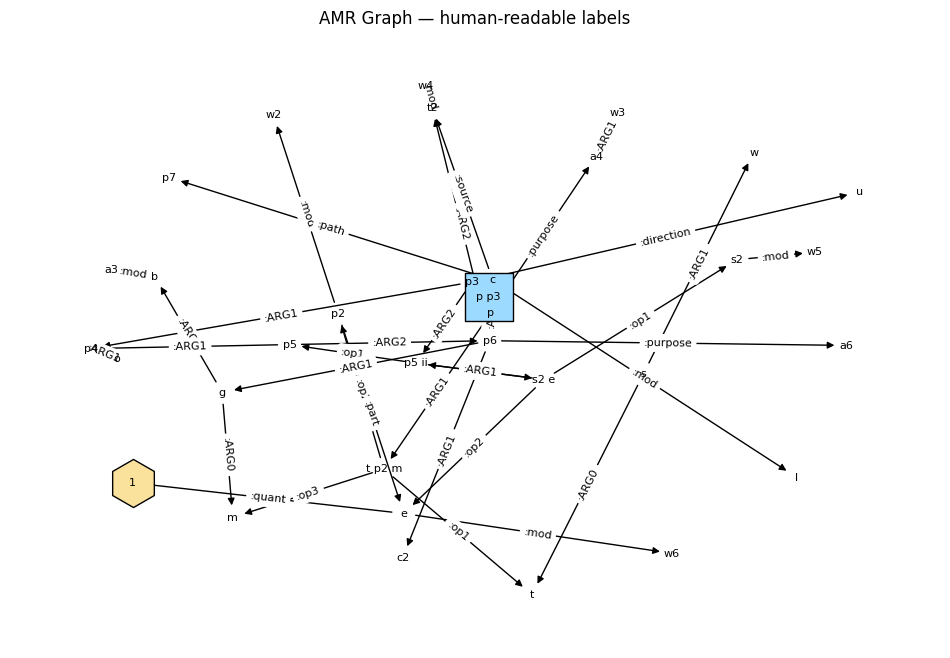

amr_graph.html
✅ Updated labels. Open amr_graph.html to explore interactively.


In [14]:
# --- Make node labels human-readable (use :name, :instance, :wiki) and re-render ---
from pyvis.network import Network
import re

# 1) Build helper maps from the PENMAN graph
inst = {s: t for s, r, t in g.triples if r == ":instance"}  # var -> concept

# Gather :name ops (op1/op2/...) and :wiki
name_parts = {}  # var -> [op1, op2, ...]
wiki = {}        # var -> "Qxxxx" or page

for s, r, t in g.triples:
    if r == ":wiki":
        wiki[s] = str(t).strip('"')
    elif r.startswith(":op"):
        # Only consider ops for nodes that have a :name relation
        # AMR often encodes names as: (x / person :name (n / name :op1 "John" :op2 "Doe"))
        # But in triple form, ops still reference the same source var as :name subtree var.
        name_parts.setdefault(s, []).append(str(t).strip('"'))
    elif r == ":name":
        # mark this var as having a name container; ops will attach to this var
        name_parts.setdefault(s, [])

# Also handle cases where name container is a separate var:
# If there are triples like (x :name n) and (n :op1 "Foo"), re-map ops from 'n' to 'x'.
name_container_edges = [(s, t) for s, r, t in g.triples if r == ":name"]
container_to_host = {container: host for host, container in name_container_edges}
if container_to_host:
    remap = {}
    for var, parts in list(name_parts.items()):
        if var in container_to_host:
            host = container_to_host[var]
            remap.setdefault(host, [])
            remap[host].extend(parts)
            del name_parts[var]
    for host, parts in remap.items():
        name_parts.setdefault(host, []).extend(parts)

# 2) Compute a pretty label for each node
def pretty_label(var_id, data):
    kind = data.get("kind")
    concept = data.get("concept", "")
    parts = name_parts.get(var_id, [])
    name_str = " ".join(parts).strip()
    if kind == "literal":
        return concept  # literal node already stores the text as 'concept'
    # Prefer explicit name if present
    if name_str:
        return name_str
    # Fall back to concept, title-case for readability (avoid overdoing for acronyms)
    if concept:
        # keep hyphens/underscores readable
        return re.sub(r"[_-]+", " ", str(concept)).strip()
    # Final fallback: the variable ID itself
    return str(var_id)

# 3) Attach labels, wiki, and root flag to nodes
root_var = getattr(g, "top", None)
for n, d in nx_graph.nodes(data=True):
    d["label"] = pretty_label(n, d)
    if n in wiki:
        d["wiki"] = wiki[n]
    if root_var is not None and n == root_var:
        d["root"] = True

# 4) Quick static check with matplotlib labels = node['label']
pos = nx.spring_layout(nx_graph, seed=7)
plt.figure(figsize=(12, 8))
for kind, shape in {"concept": "s", "literal": "h", "other": "o"}.items():
    nodes = [n for n, d in nx_graph.nodes(data=True) if d.get("kind") == kind]
    if nodes:
        nx.draw_networkx_nodes(
            nx_graph, pos, nodelist=nodes,
            node_shape=shape,
            node_color=[nx_graph.nodes[n].get("color", "#cbe5b6") for n in nodes],
            node_size=1200, edgecolors="black",
        )

nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowstyle="-|>")
nx.draw_networkx_labels(nx_graph, pos,
                        labels={n: d.get("label", n) for n, d in nx_graph.nodes(data=True)},
                        font_size=8)
nx.draw_networkx_edge_labels(nx_graph, pos,
                             edge_labels={(u, v): d.get("role", "") for u, v, d in nx_graph.edges(data=True)},
                             font_size=8)
plt.title("AMR Graph — human-readable labels")
plt.axis("off")
plt.show()

# 5) PyVis interactive with nice tooltips
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    hover = (
        f"<b>id</b>: {n}"
        f"<br><b>concept</b>: {d.get('concept','')}"
        f"<br><b>label</b>: {d.get('label','')}"
        + (f"<br><b>wiki</b>: {d.get('wiki')}" if d.get("wiki") else "")
        + (f"<br><b>root</b>: {d.get('root')}" if d.get("root") else "")
    )
    net.add_node(
        n,
        label=d.get("label", str(n)),
        title=hover,
        color=d.get("color", "#cbe5b6"),
        shape="box" if d.get("shape") == "square" else ("hexagon" if d.get("shape") == "hexagon" else "ellipse"),
    )

for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html" , notebook=None)
print("✅ Updated labels. Open amr_graph.html to explore interactively.")


In [14]:
import os, pyvis, jinja2, sys
print("pyvis:", pyvis.__version__, "->", pyvis.__file__)
print("jinja2:", jinja2.__version__)
# Check if the template exists on disk:
tmpl_dir = os.path.join(os.path.dirname(pyvis.__file__), "templates")
print("template dir exists:", os.path.isdir(tmpl_dir))
if os.path.isdir(tmpl_dir):
    print("has template.html:", os.path.isfile(os.path.join(tmpl_dir, "template.html")))


pyvis: 0.3.2 -> c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\pyvis\__init__.py
jinja2: 3.1.6
template dir exists: True
has template.html: True
